# Machine Learning Capstone — Review 1

## Air Quality Prediction using `city_day.csv`

**Review 1 scope:** Regression Track (Member 1 & Member 2 sections).

This notebook covers:
- Dataset loading and audit
- Exploratory Data Analysis (EDA)
- Data cleaning and preprocessing
- Feature engineering
- 10 required regression algorithms
- Hyperparameter tuning for 2 regression models
- Regression evaluation and visualisation
- 5-fold cross-validation for the two best regression models

**Random state:** 42

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

## 1. Load Dataset

In [2]:
df = pd.read_csv("city_day.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (29531, 16)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


## 2. Dataset Audit

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nData Types:")
display(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe(include="all").T)

Number of rows: 29531
Number of columns: 16

Data Types:


City              str
Date              str
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket        str
dtype: object


Missing Values:


City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64


Duplicate Rows: 0

Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
City,29531,26,Ahmedabad,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,29531,2009,2020-03-11,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PM2.5,24933.0,NaN,NaN,NaN,67.450578,64.661449,0.04,28.82,48.57,80.59,949.99
PM10,18391.0,NaN,NaN,NaN,118.127103,90.60511,0.01,56.255,95.68,149.745,1000.0
NO,25949.0,NaN,NaN,NaN,17.57473,22.785846,0.02,5.63,9.89,19.95,390.68
NO2,25946.0,NaN,NaN,NaN,28.560659,24.474746,0.01,11.75,21.69,37.62,362.21
NOx,25346.0,NaN,NaN,NaN,32.309123,31.646011,0.0,12.82,23.52,40.1275,467.63
NH3,19203.0,NaN,NaN,NaN,23.483476,25.684275,0.01,8.58,15.85,30.02,352.89
CO,27472.0,NaN,NaN,NaN,2.248598,6.962884,0.0,0.51,0.89,1.45,175.81
SO2,25677.0,NaN,NaN,NaN,14.531977,18.133775,0.01,5.67,9.16,15.22,193.86


## 3. Target Distribution

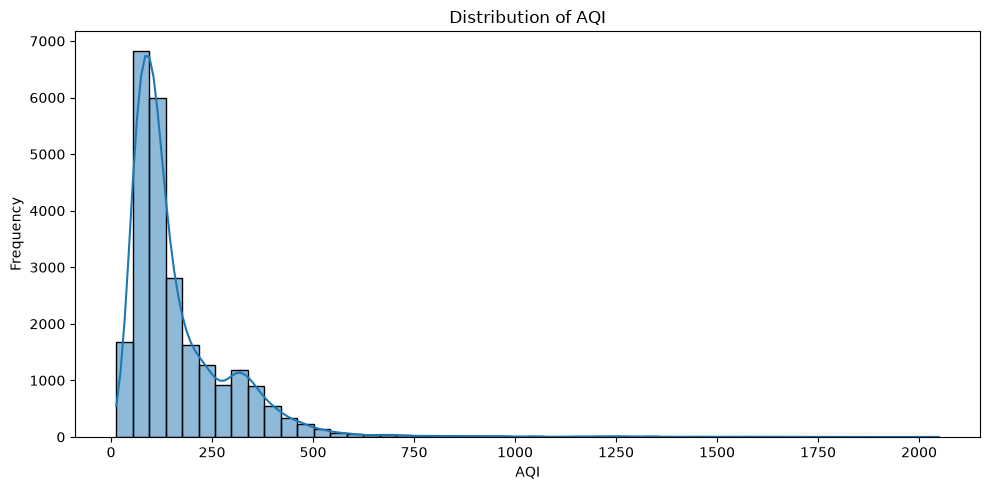

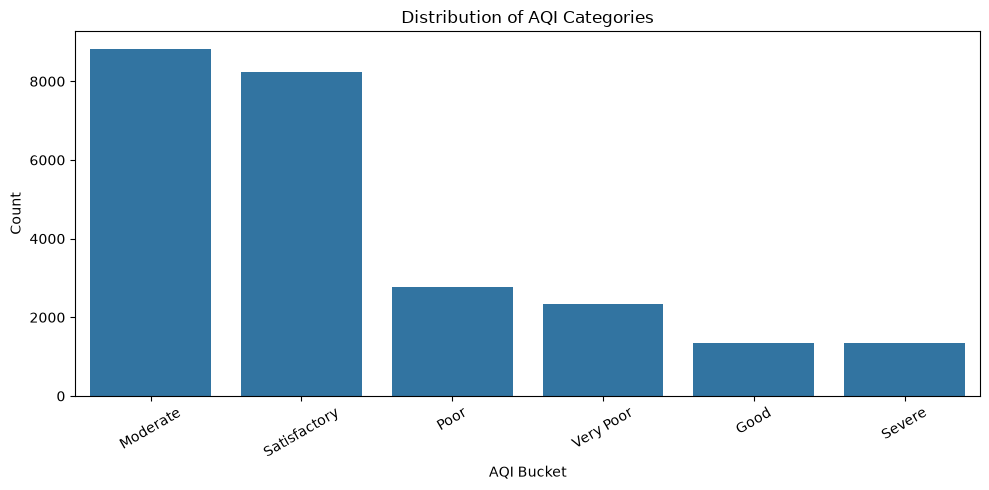

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(df["AQI"], bins=50, kde=True)
plt.title("Distribution of AQI")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x="AQI_Bucket",
    order=df["AQI_Bucket"].value_counts().index
)
plt.title("Distribution of AQI Categories")
plt.xlabel("AQI Bucket")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 4. Exploratory Data Analysis — Feature Distributions

Numerical columns: ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']


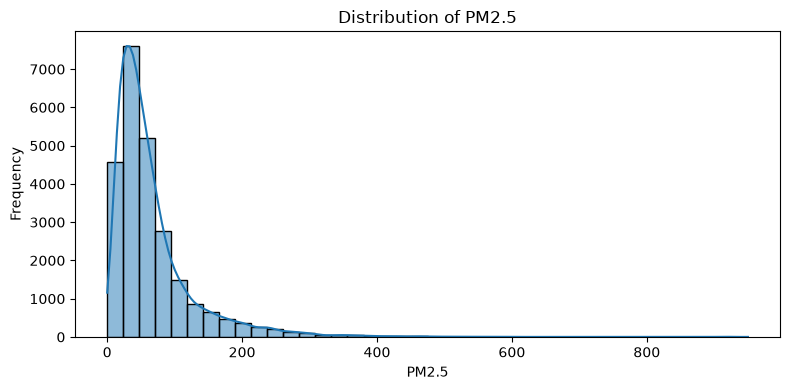

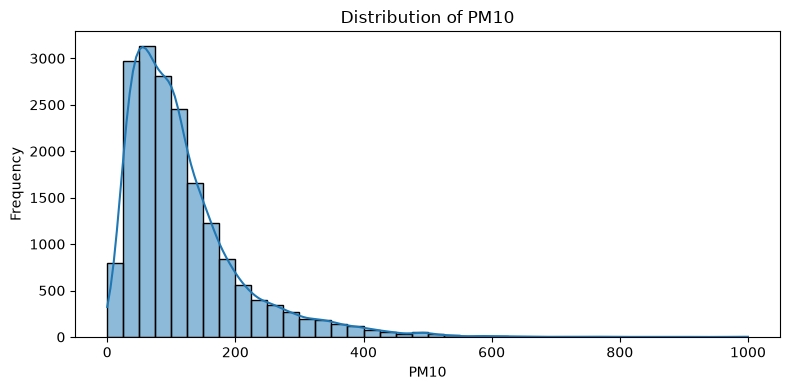

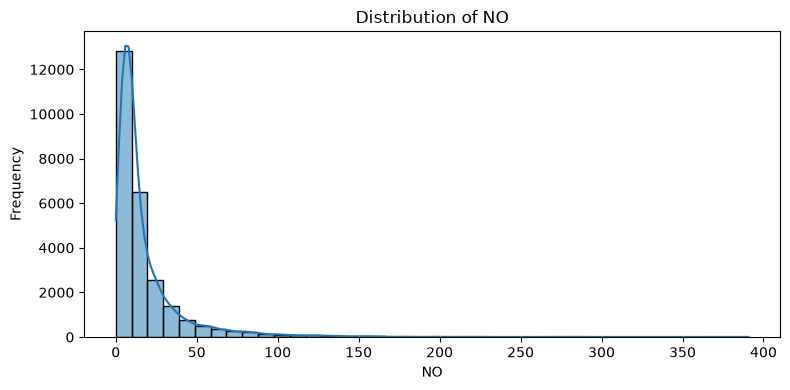

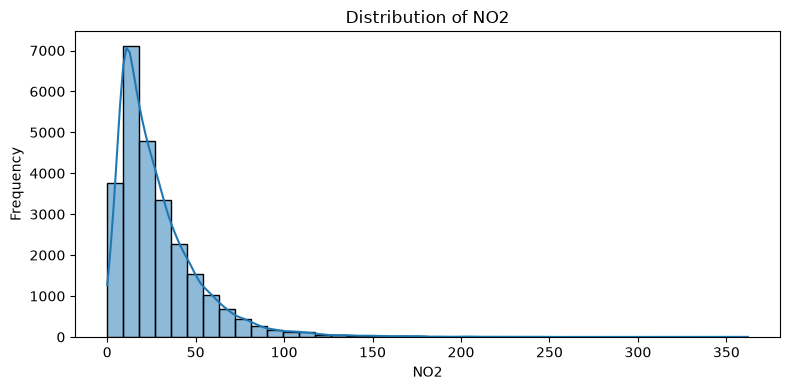

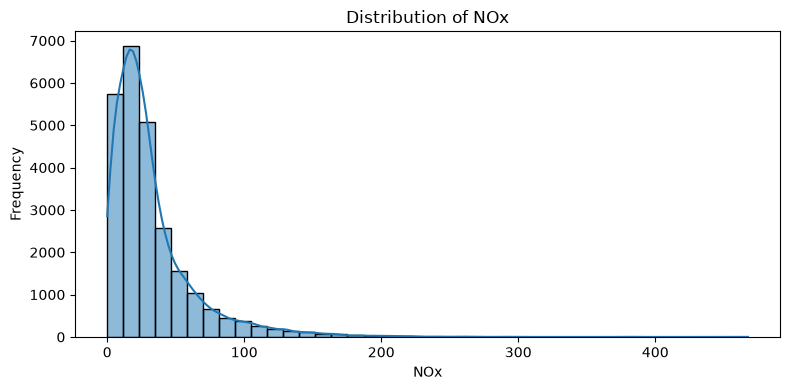

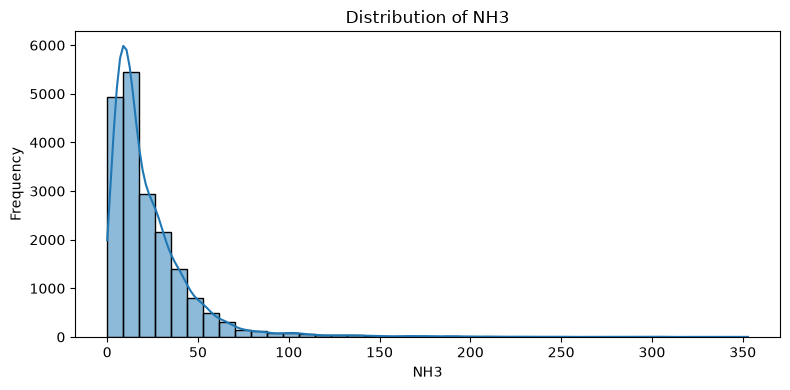

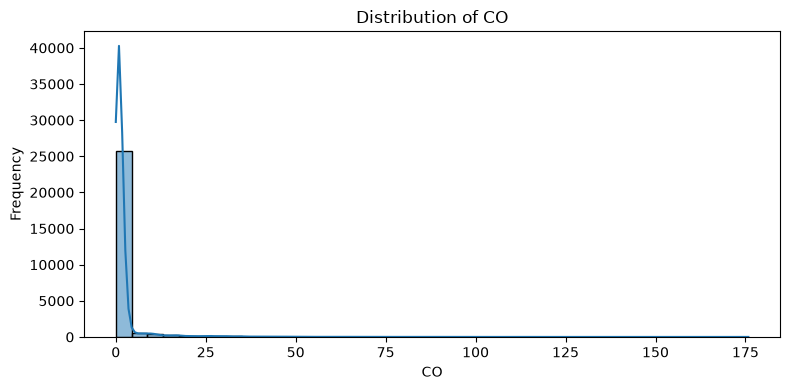

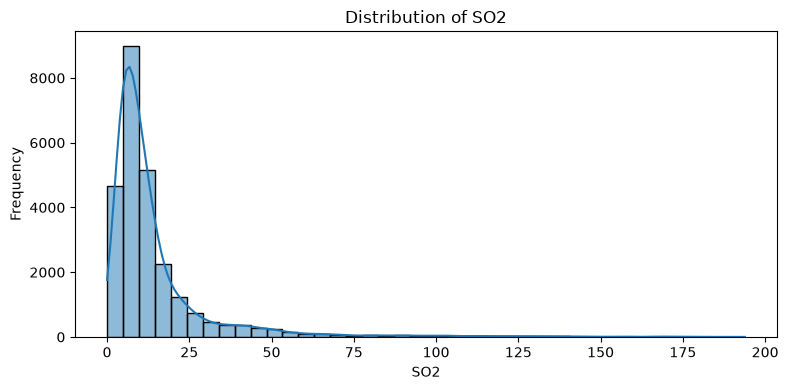

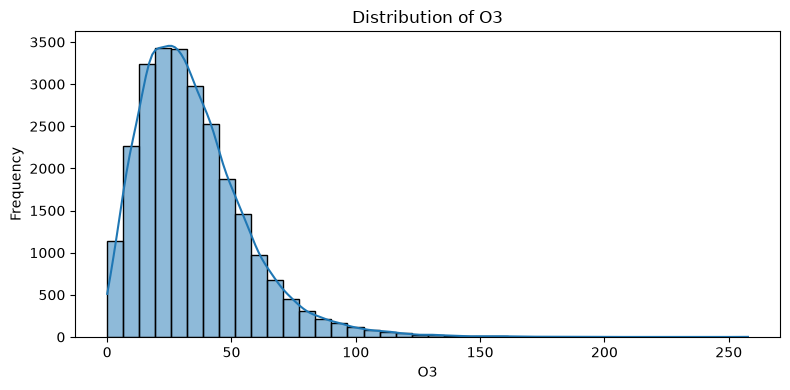

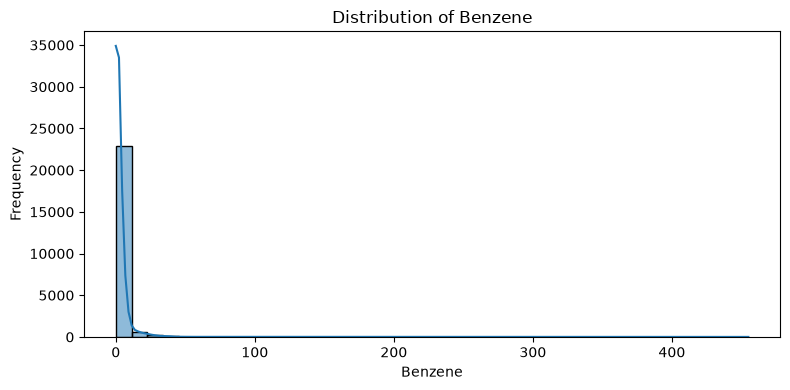

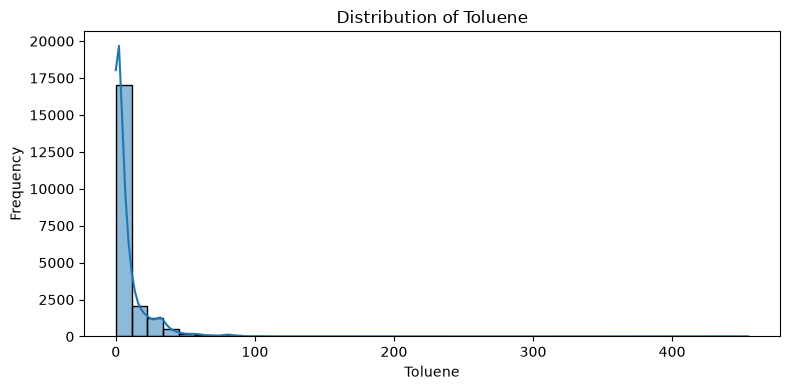

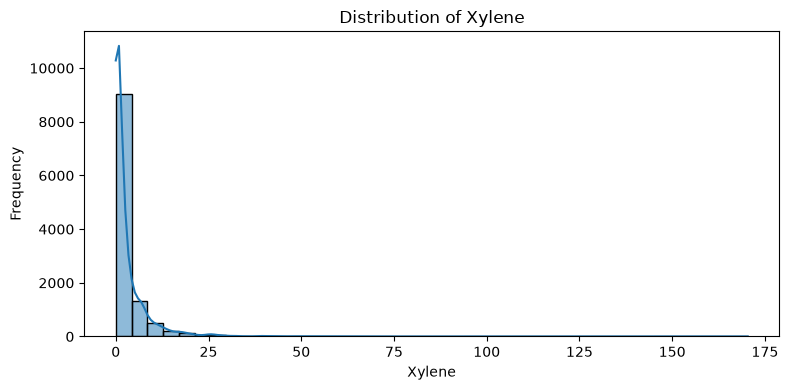

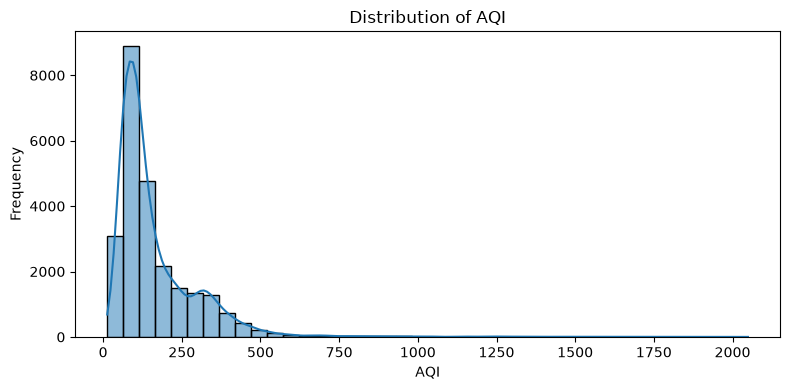

In [5]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
print("Numerical columns:", numeric_columns)

for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[column], bins=40, kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## 5. Correlation Heatmap

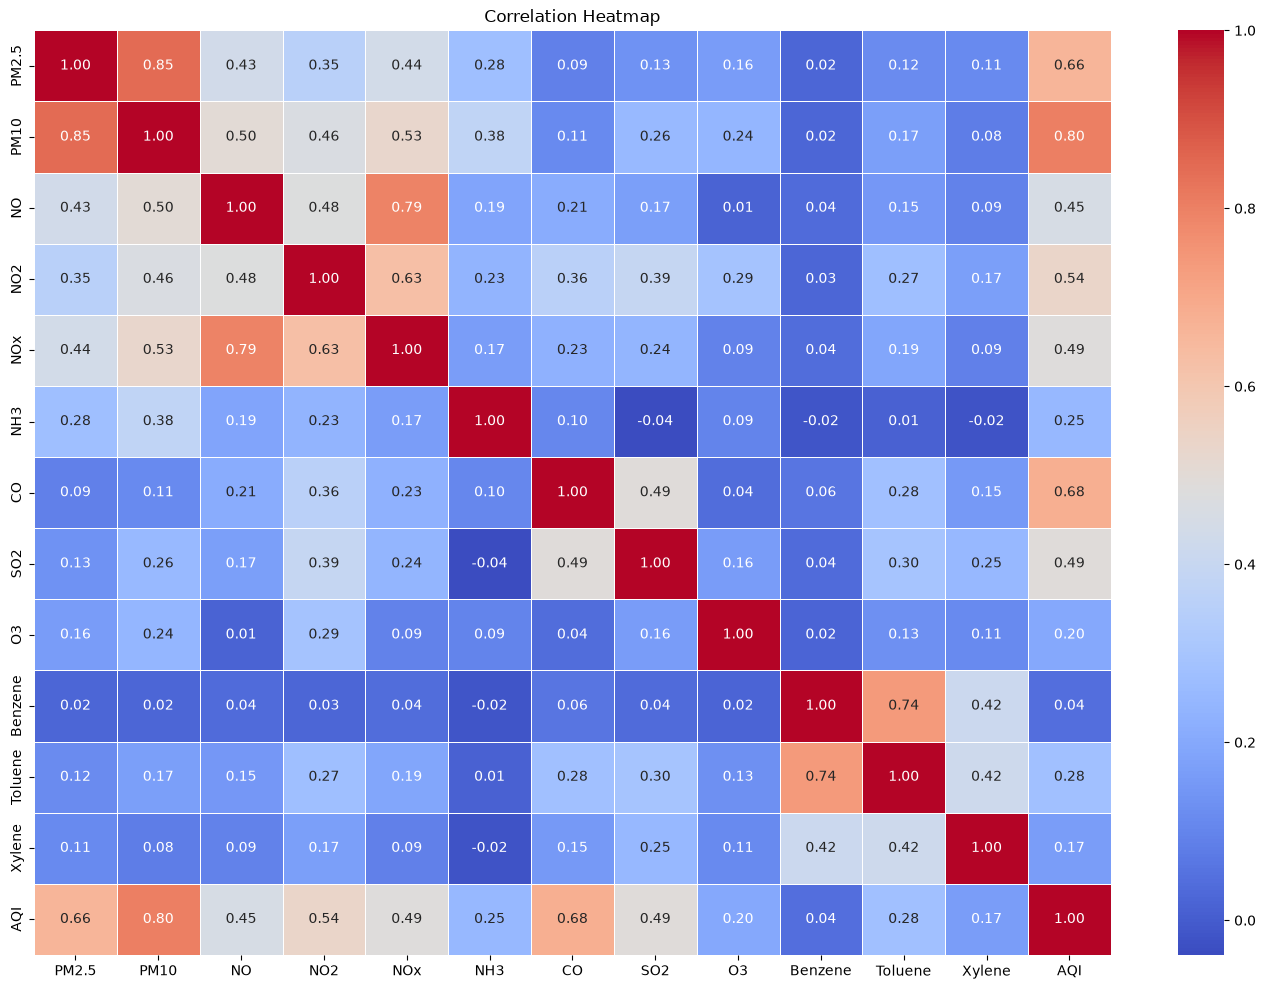

In [6]:
plt.figure(figsize=(14, 10))
correlation = df[numeric_columns].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 6. Feature–Target Relationships

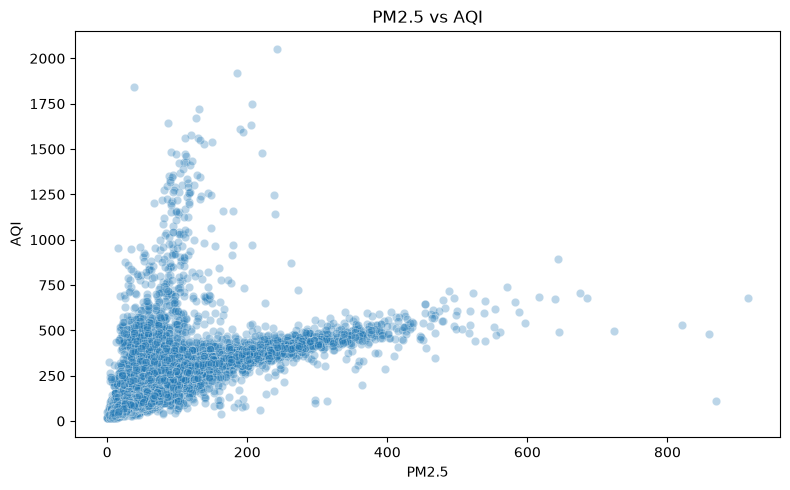

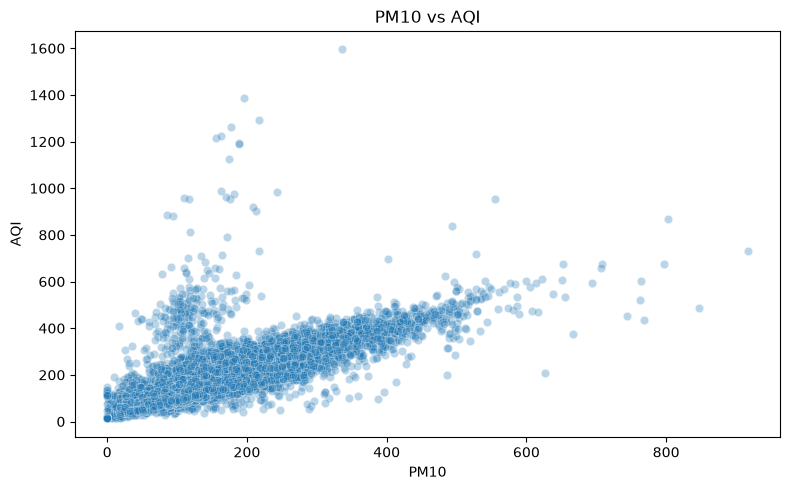

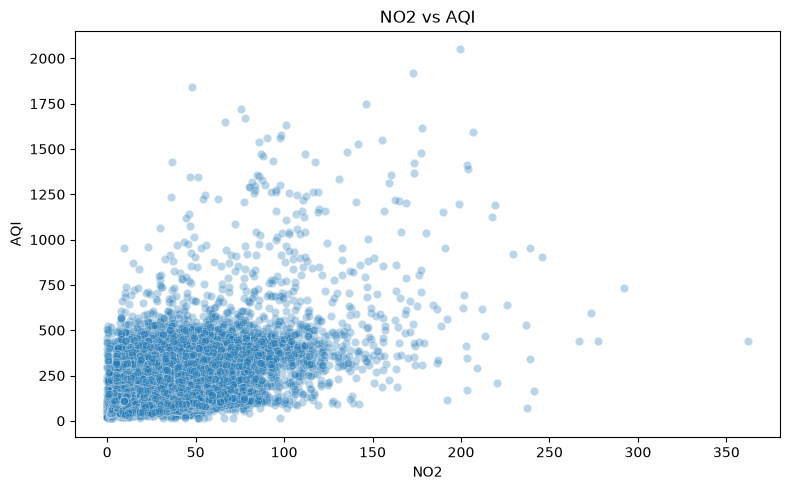

In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="PM2.5", y="AQI", alpha=0.3)
plt.title("PM2.5 vs AQI")
plt.xlabel("PM2.5")
plt.ylabel("AQI")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="PM10", y="AQI", alpha=0.3)
plt.title("PM10 vs AQI")
plt.xlabel("PM10")
plt.ylabel("AQI")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="NO2", y="AQI", alpha=0.3)
plt.title("NO2 vs AQI")
plt.xlabel("NO2")
plt.ylabel("AQI")
plt.tight_layout()
plt.show()

## 7. Date Feature Engineering

In [8]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

df.drop("Date", axis=1, inplace=True)

display(df.head())

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Year,Month,Day,DayOfWeek
0,Ahmedabad,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN,2015,1,1,3
1,Ahmedabad,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN,2015,1,2,4
2,Ahmedabad,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN,2015,1,3,5
3,Ahmedabad,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN,2015,1,4,6
4,Ahmedabad,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN,2015,1,5,0


### Feature engineering justification

The `Date` column is decomposed into `Year`, `Month`, `Day`, and `DayOfWeek`. These numerical representations allow machine-learning models to use temporal information that cannot be directly learned from a raw date string.

## 8. Outlier Inspection

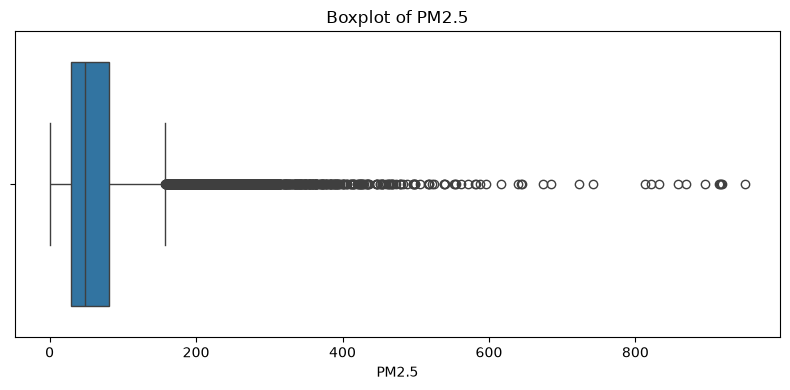

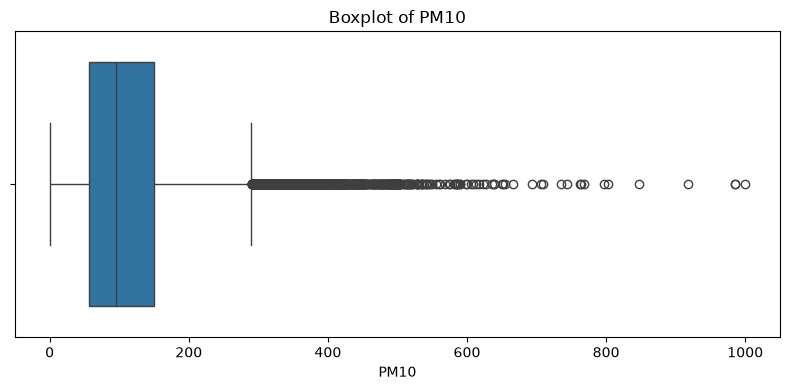

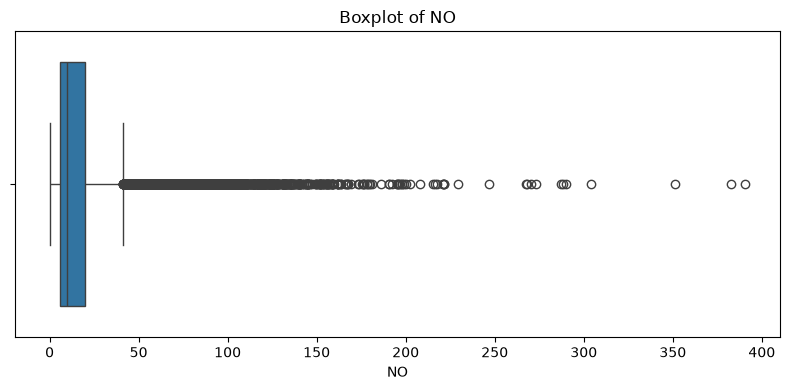

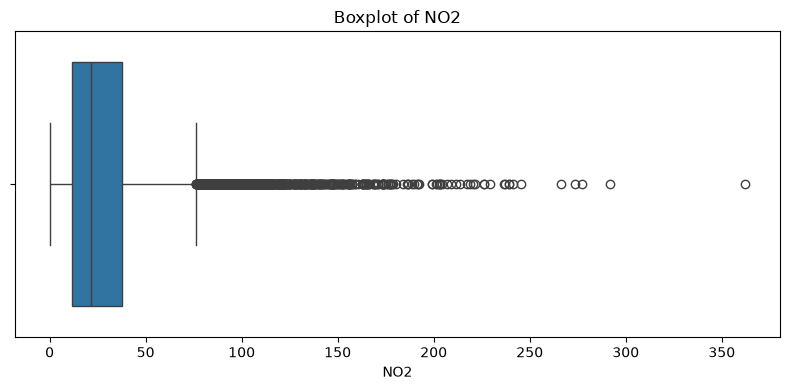

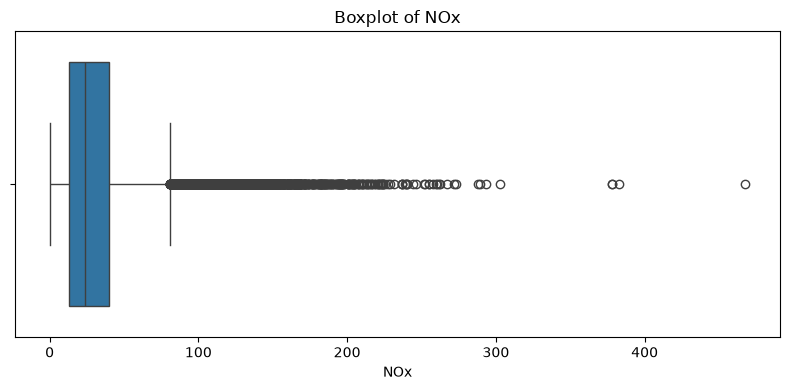

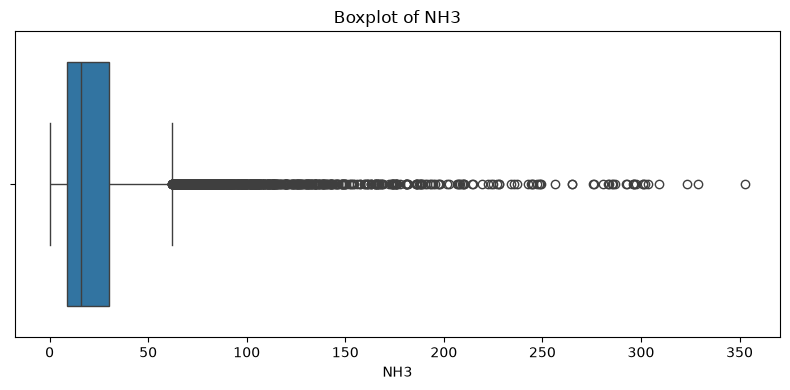

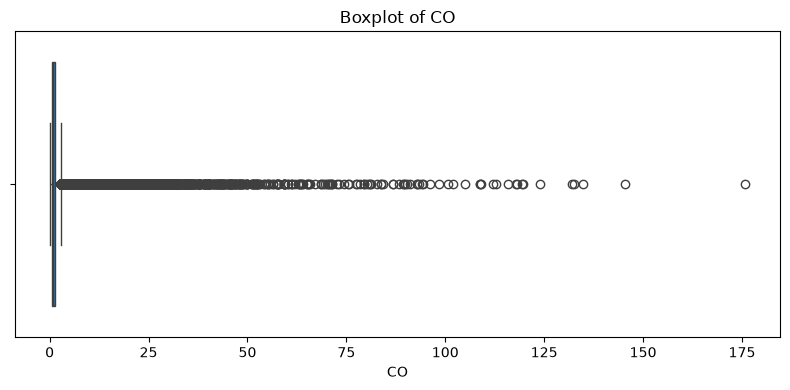

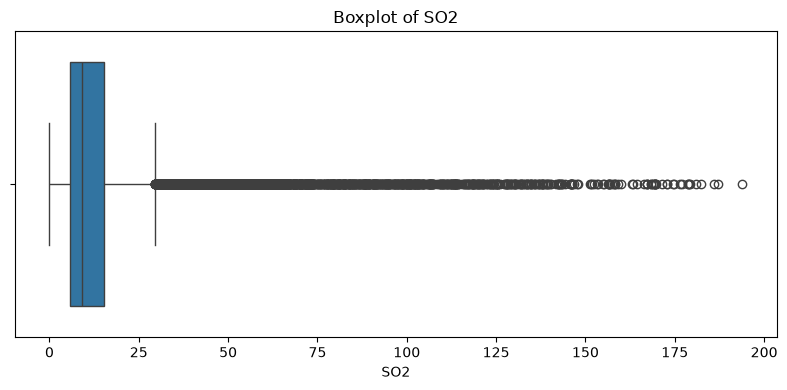

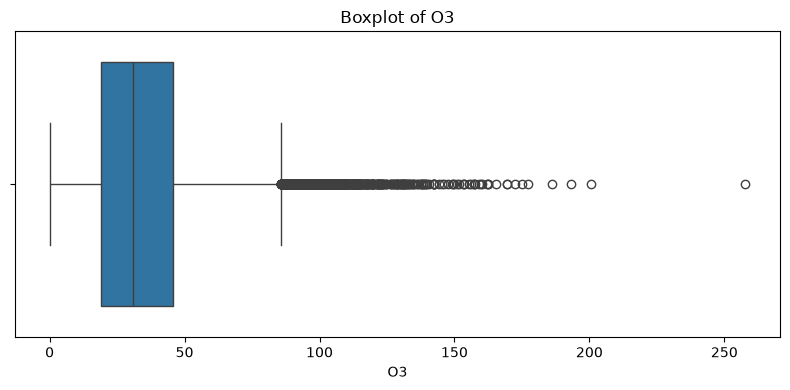

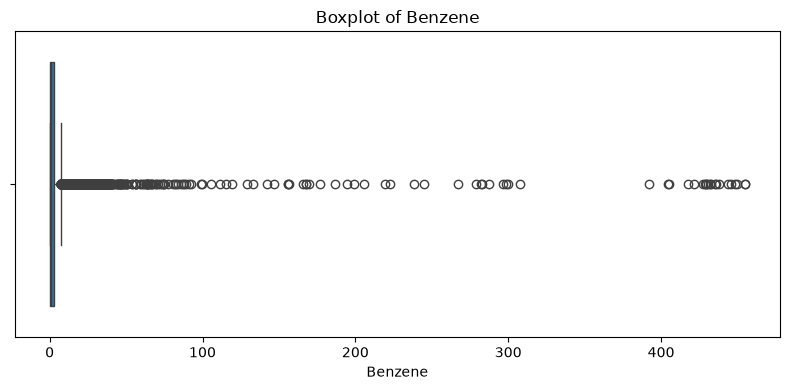

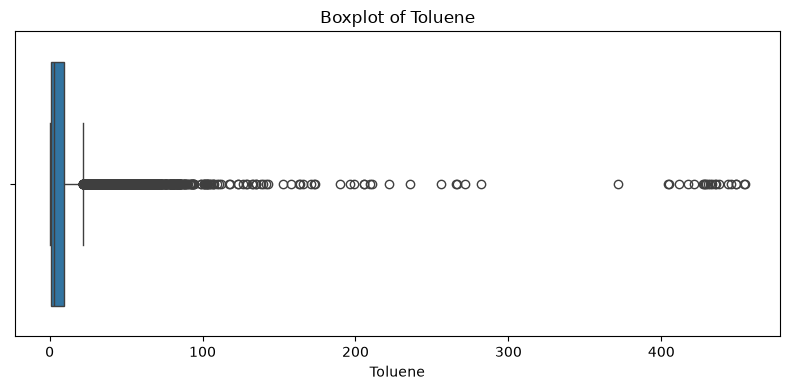

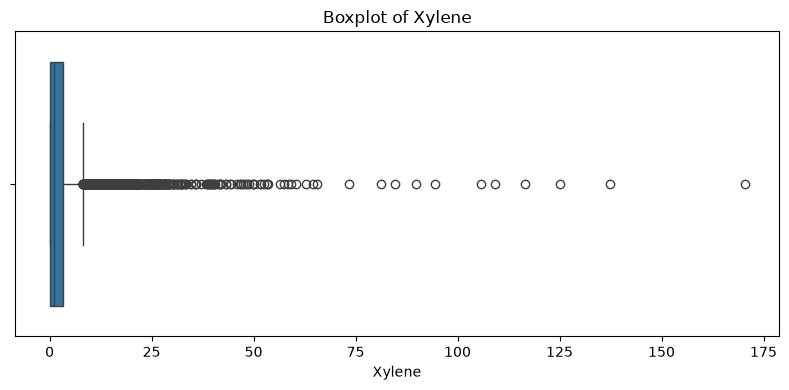

In [9]:
for column in numeric_columns:
    if column != "AQI":
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df[column])
        plt.title(f"Boxplot of {column}")
        plt.xlabel(column)
        plt.tight_layout()
        plt.show()

### Outlier treatment

Rather than deleting large numbers of observations based only on visual inspection, numerical missing values will be handled using median imputation inside the preprocessing pipeline. This keeps the preprocessing consistent and prevents data leakage because the imputer and scaler are fitted only on the training data.

# PART I — REGRESSION

## 9. Prepare Regression Dataset

`AQI` is the regression target.

`AQI_Bucket` is removed because it is derived from AQI and would introduce target leakage if used to predict AQI.

In [10]:
regression_df = df.drop("AQI_Bucket", axis=1).copy()
regression_df = regression_df.dropna(subset=["AQI"])

X_reg = regression_df.drop("AQI", axis=1)
y_reg = regression_df["AQI"]

print("X shape:", X_reg.shape)
print("y shape:", y_reg.shape)

X shape: (24850, 17)
y shape: (24850,)


## 10. Identify Numerical and Categorical Features

In [11]:
categorical_features = X_reg.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X_reg.select_dtypes(include=np.number).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['City']

Numerical Features:
['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'Year', 'Month', 'Day', 'DayOfWeek']


## 11. Train/Test Split

In [12]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training samples:", X_train_reg.shape[0])
print("Testing samples:", X_test_reg.shape[0])

Training samples: 19880
Testing samples: 4970


## 12. Regression Preprocessing Pipeline

In [13]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 13. Define the 10 Required Regression Algorithms

In [14]:
regression_models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(alpha=1.0),

    "Lasso Regression": Lasso(alpha=0.01),

    "ElasticNet Regression": ElasticNet(alpha=0.01, l1_ratio=0.5),

    "Polynomial Regression": Pipeline([
        ("poly", PolynomialFeatures(degree=2)),
        ("linear", LinearRegression())
    ]),

    "Decision Tree": DecisionTreeRegressor(
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),

    "SVR": SVR(
        C=10,
        kernel="rbf"
    ),

    "KNN": KNeighborsRegressor(
        n_neighbors=5
    )
}

## 14. Train All 10 Regression Models

In [15]:
regression_results = []
trained_regression_models = {}

for name, model in regression_models.items():

    print(f"Training {name}...")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train_reg, y_train_reg)
    predictions = pipeline.predict(X_test_reg)

    r2 = r2_score(y_test_reg, predictions)
    rmse = np.sqrt(mean_squared_error(y_test_reg, predictions))
    mae = mean_absolute_error(y_test_reg, predictions)

    regression_results.append({
        "Model": name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    })

    trained_regression_models[name] = pipeline

regression_results_df = pd.DataFrame(regression_results)
regression_results_df = (
    regression_results_df
    .sort_values(by="R2", ascending=False)
    .reset_index(drop=True)
)

display(regression_results_df)

Training Linear Regression...
Training Ridge Regression...
Training Lasso Regression...
Training ElasticNet Regression...
Training Polynomial Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training SVR...
Training KNN...


,Model,R2,RMSE,MAE
0,Random Forest,0.912279,40.078205,20.333672
1,Gradient Boosting,0.897152,43.396376,23.246403
2,Polynomial Regression,0.892048,44.460197,24.266695
3,KNN,0.874717,47.896355,25.684306
4,Decision Tree,0.835178,54.936805,28.080684
5,Linear Regression,0.824474,56.692716,29.968659
6,Ridge Regression,0.824472,56.692998,29.967562
7,Lasso Regression,0.824358,56.711398,29.948714
8,ElasticNet Regression,0.824221,56.733580,29.922186
9,SVR,0.775052,64.179584,25.748531


## 15. Regression Model Comparison

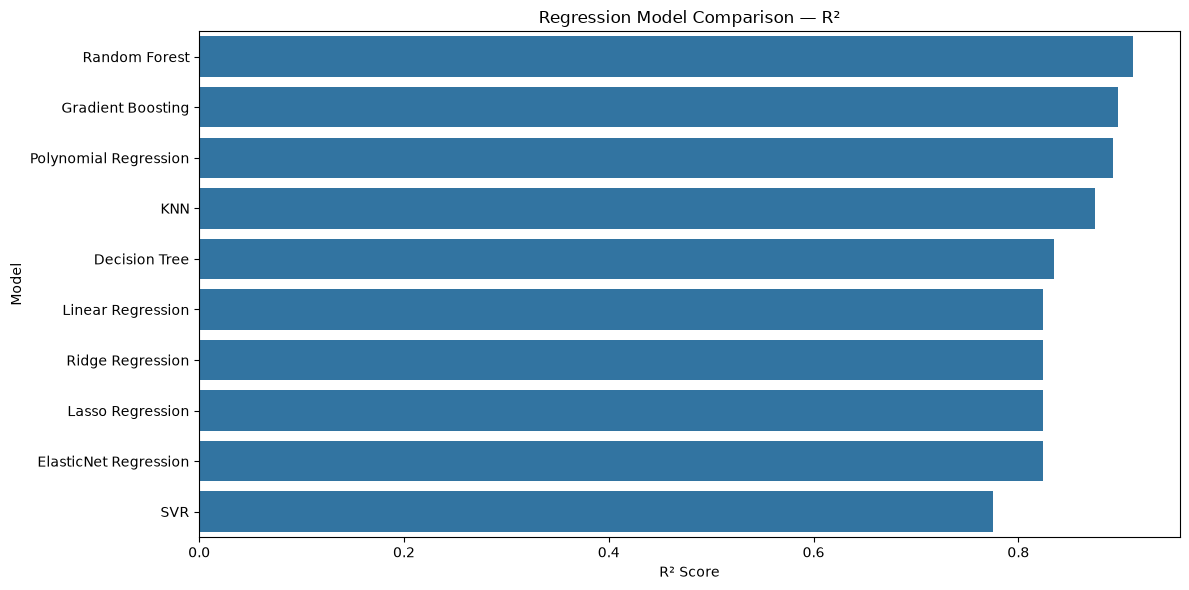

In [16]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=regression_results_df,
    x="R2",
    y="Model"
)

plt.title("Regression Model Comparison — R²")
plt.xlabel("R² Score")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

## 16. Hyperparameter Tuning — Random Forest

In [ ]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train_reg, y_train_reg)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest CV R²:")
print(rf_grid.best_score_)

## 17. Hyperparameter Tuning — Ridge Regression

In [ ]:
ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge())
    ]
)

ridge_params = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge_pipeline,
    ridge_params,
    cv=5,
    scoring="r2"
)

ridge_grid.fit(X_train_reg, y_train_reg)

print("Best Ridge Parameters:")
print(ridge_grid.best_params_)

print("\nBest CV R²:")
print(ridge_grid.best_score_)

Best Ridge Parameters:
{'model__alpha': 10}

Best CV R²:
0.8640944977036156


## 18. Evaluate Tuned Models

In [ ]:
tuned_models = {
    "Tuned Random Forest": rf_grid.best_estimator_,
    "Tuned Ridge": ridge_grid.best_estimator_
}

tuned_results = []

for name, model in tuned_models.items():

    predictions = model.predict(X_test_reg)

    tuned_results.append({
        "Model": name,
        "R2": r2_score(y_test_reg, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test_reg, predictions)),
        "MAE": mean_absolute_error(y_test_reg, predictions)
    })

tuned_results_df = pd.DataFrame(tuned_results)
display(tuned_results_df)

,Model,R2,RMSE,MAE
0,Tuned Random Forest,0.912048,40.130852,20.336177
1,Tuned Ridge,0.824455,56.695724,29.958590


## 19. 5-Fold Cross-Validation for the Two Best Models

In [ ]:
best_two_models = regression_results_df.head(2)

cv_results = []

for model_name in best_two_models["Model"]:

    model = trained_regression_models[model_name]

    scores = cross_val_score(
        model,
        X_reg,
        y_reg,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "CV R2 Mean": scores.mean(),
        "CV R2 Std": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

display(cv_results_df)

,Model,CV R2 Mean,CV R2 Std
0,Random Forest,0.768397,0.236886
1,Gradient Boosting,0.759570,0.252768


## 20. Select Best Regression Model

In [ ]:
best_model_name = regression_results_df.iloc[0]["Model"]
best_model = trained_regression_models[best_model_name]

best_predictions = best_model.predict(X_test_reg)

print("Best Model:", best_model_name)
print("R²:", r2_score(y_test_reg, best_predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, best_predictions)))
print("MAE:", mean_absolute_error(y_test_reg, best_predictions))

Best Model: Random Forest
R²: 0.9122789229723218
RMSE: 40.078204772252455
MAE: 20.33367203219316


## 21. Predicted vs Actual Plot

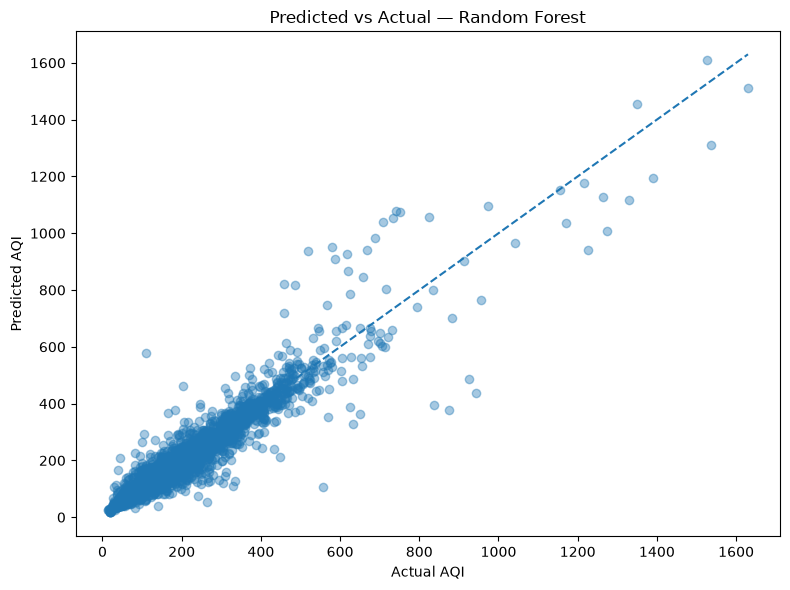

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_reg,
    best_predictions,
    alpha=0.4
)

plt.plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()],
    linestyle="--"
)

plt.title(f"Predicted vs Actual — {best_model_name}")
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.tight_layout()
plt.show()

## 22. Residual Plot

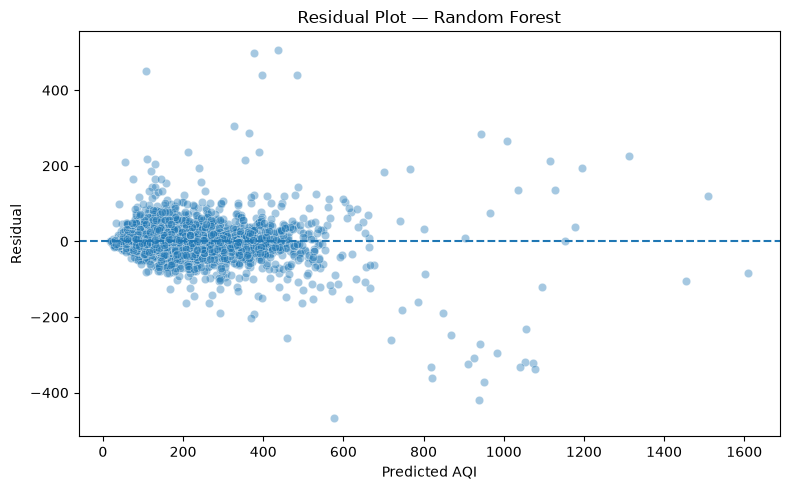

In [ ]:
residuals = y_test_reg - best_predictions

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=best_predictions,
    y=residuals,
    alpha=0.4
)

plt.axhline(0, linestyle="--")

plt.title(f"Residual Plot — {best_model_name}")
plt.xlabel("Predicted AQI")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

## 23. Random Forest Feature Importance

,Feature,Importance
0,num__PM2.5,0.488998
6,num__CO,0.364747
2,num__NO,0.035934
1,num__PM10,0.035376
8,num__O3,0.012460
4,num__NOx,0.009549
7,num__SO2,0.007751
10,num__Toluene,0.006140
3,num__NO2,0.005989
14,num__Day,0.005420


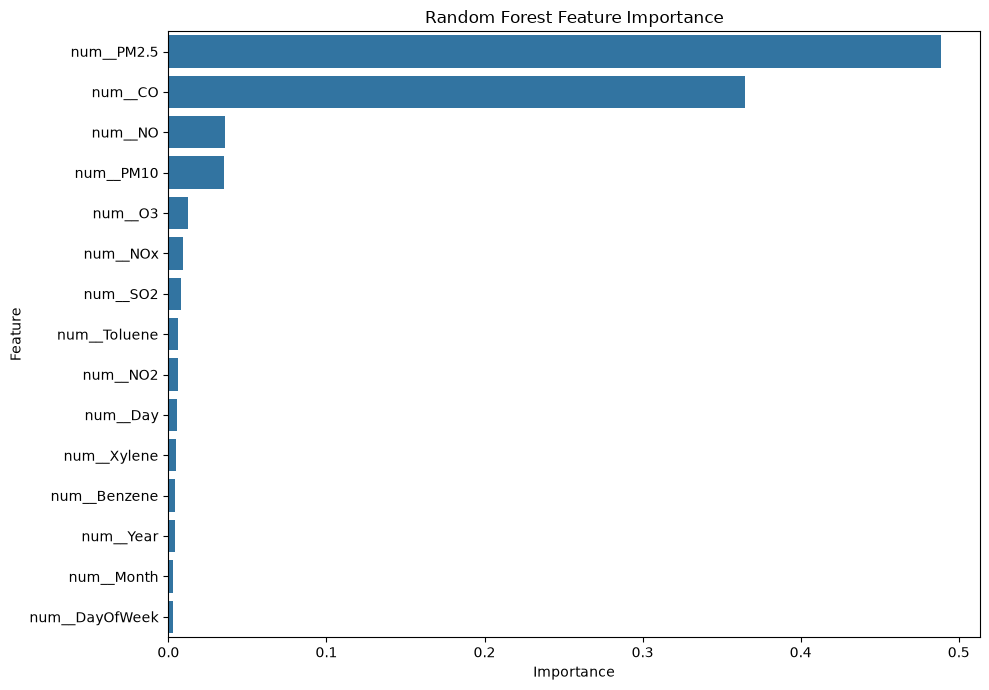

In [ ]:
rf_model = trained_regression_models["Random Forest"]

feature_names = (
    rf_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    rf_model
    .named_steps["model"]
    .feature_importances_
)

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance_df = (
    feature_importance_df
    .sort_values(by="Importance", ascending=False)
    .head(15)
)

display(feature_importance_df)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 24. Final Review 1 Results

In [ ]:
print("REGRESSION RESULTS")
display(regression_results_df)

print("\nTUNED REGRESSION RESULTS")
display(tuned_results_df)

print("\n5-FOLD CROSS-VALIDATION RESULTS")
display(cv_results_df)

REGRESSION RESULTS


,Model,R2,RMSE,MAE
0,Random Forest,0.912279,40.078205,20.333672
1,Gradient Boosting,0.897152,43.396376,23.246403
2,Polynomial Regression,0.892048,44.460197,24.266695
3,KNN,0.874717,47.896355,25.684306
4,Decision Tree,0.835178,54.936805,28.080684
5,Linear Regression,0.824474,56.692716,29.968659
6,Ridge Regression,0.824472,56.692998,29.967562
7,Lasso Regression,0.824358,56.711398,29.948714
8,ElasticNet Regression,0.824221,56.733580,29.922186
9,SVR,0.775052,64.179584,25.748531



TUNED REGRESSION RESULTS


,Model,R2,RMSE,MAE
0,Tuned Random Forest,0.912048,40.130852,20.336177
1,Tuned Ridge,0.824455,56.695724,29.958590



5-FOLD CROSS-VALIDATION RESULTS


,Model,CV R2 Mean,CV R2 Std
0,Random Forest,0.768397,0.236886
1,Gradient Boosting,0.759570,0.252768



CLASSIFICATION PART-A RESULTS


,Model,Accuracy,Precision,Recall,F1 Score
0,SVM,0.789135,0.788480,0.789135,0.784999
1,Logistic Regression,0.769819,0.766682,0.769819,0.765158
2,KNN,0.740644,0.737162,0.740644,0.737571
3,Decision Tree,0.732596,0.732859,0.732596,0.732501
4,Naive Bayes,0.144064,0.530632,0.144064,0.095545


# Review 1 Conclusion

## Regression

The ten required regression algorithms were trained and evaluated using the same train/test split. The models were compared using R², RMSE and MAE. Hyperparameter tuning was performed for Random Forest and Ridge Regression, and 5-fold cross-validation was performed for the two best-performing regression models.